# Model Comparison Plot

Compares Cox PH, Random Survival Forest, and Gradient Boosting Survival Analysis across two feature sets (`mm_nopgs`, `mm_pgs_score`). C-Indices of the different models were copy-pasted in here from their respective notebooks [random_survival_forest.ipynb](./random_survival_forest.ipynb), [gradient_boosted_machine.ipynb](./gradient_boosted_machine.ipynb) and [evaluate_final_models.ipynb](./evaluate_final_models.ipynb) to avoid re-training all models in this notebook. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Cox-PH results (from evaluate_final_models.ipynb)
cox_nopgs_scores = [0.6898]
cox_pgs_scores = [0.7088]

# RSF results (from random_survival_forest.ipynb)
rsf_nopgs_scores = [0.668789, 0.678882, 0.677411, 0.678096, 0.679203]  # n_estimators: 20,50,100,150,200
rsf_pgs_scores   = [0.687112, 0.684897, 0.688921, 0.691733, 0.691863]

# GBM results (from gradient_boosting.ipynb)
gbm_nopgs_scores = [0.690237, 0.684631, 0.684539, 0.684179, 0.682523,
                    0.678365, 0.677292, 0.676076, 0.675512, 0.669283]
gbm_pgs_scores   = [0.704647, 0.694718, 0.694613, 0.694335, 0.690794,
                    0.690421, 0.689836, 0.687449, 0.685226, 0.683755]

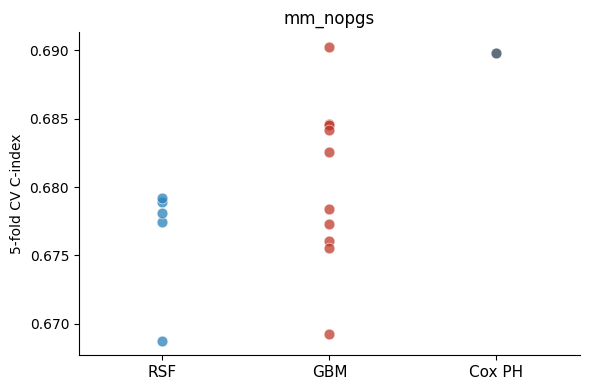

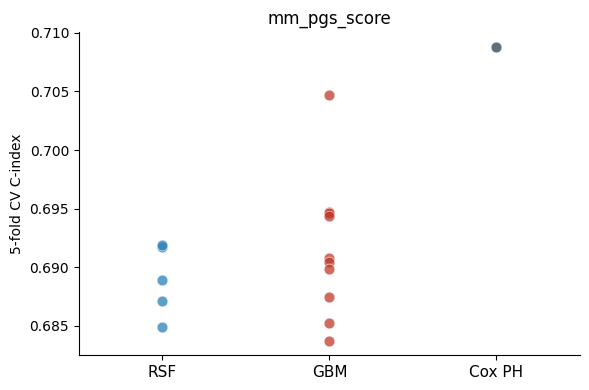

In [8]:
def comparison_plot(cox_scores, rsf_scores, gbm_scores, title):
    rng = np.random.default_rng(0)

    groups = [
        ('RSF',     rsf_scores, '#2980b9'),
        ('GBM',     gbm_scores, '#c0392b'),
        ('Cox PH',  cox_scores, '#2c3e50'),
    ]

    fig, ax = plt.subplots(figsize=(6, 4))

    for i, (label, scores, color) in enumerate(groups):
        ax.scatter(np.repeat(i, len(scores)), scores, color=color, alpha=0.75, s=60, edgecolors='white', linewidths=0.5, label=label, zorder=3)

    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels([g[0] for g in groups], fontsize=11)
    ax.set_ylabel('5-fold CV C-index', fontsize=10)
    ax.set_title(title, fontsize=12)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xlim(-0.5, 2.5)
    plt.savefig(f'img/model_comparison_{title}.svg')
    plt.tight_layout()
    plt.show()

comparison_plot(cox_nopgs_scores, rsf_nopgs_scores, gbm_nopgs_scores, 'mm_nopgs')
comparison_plot(cox_pgs_scores,   rsf_pgs_scores,   gbm_pgs_scores,   'mm_pgs_score')